# Large Cube Hybrid Relaxation Benchmark

This notebook tests the better relaxation strategy found in `neuralmag_cube_lbfgs_relaxation_benchmark.ipynb` on a large cube, without modifying the original fit notebook.

Strategy under test:

`normalized effective-field projected-gradient warmup -> NeuralMag BB/Cayley relaxation`

The metric to watch is the tangent equilibrium residual `max_g`, because a smaller residual makes subsequent implicit differentiation more trustworthy.

In [1]:
from __future__ import annotations

import os
import sys
import time
from pathlib import Path

os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.90")

from jax import config as jax_config
jax_config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
repo_candidates = [cwd, *cwd.parents, Path("/Users/landers/LiberTEM-holo")]
repo_root = next((path for path in repo_candidates if (path / "pyproject.toml").exists()), cwd)
for import_path in (repo_root / "src", repo_root / "vendor" / "neuralmag"):
    if import_path.exists():
        sys.path.insert(0, str(import_path))

import neuralmag as nm

nm.config.dtype = "float64"
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"Repo root: {repo_root}")
print(f"NeuralMag backend: {getattr(nm.config.backend, 'name', nm.config.backend)}")
print(f"JAX devices: {jax.devices()}")


2026-05-02 16:05:39 NeuralMag:INFO [NeuralMag] Version 0.9.4


2026-05-02 16:05:39 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.


2026-05-02 16:05:39 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


Repo root: /Users/landers/LiberTEM-holo
NeuralMag backend: jax


JAX devices: [CudaDevice(id=0)]


## Controls

The default `run_mode = "large"` uses the same nominal cube size as the fit notebook: `80 nm / 1 nm = 80^3` cells. Set `run_mode = "smoke"` for a quick validation run.

In [2]:
run_mode = "large"  # "large" or "smoke"

if run_mode == "large":
    outer_edge_length_nm = 80.0
    cell_size_nm = 1.0
    demag_p = 3
    normalized_pg_steps = 500
    bb_steps = 500
elif run_mode == "smoke":
    outer_edge_length_nm = 24.0
    cell_size_nm = 2.0
    demag_p = 1
    normalized_pg_steps = 100
    bb_steps = 100
else:
    raise ValueError(f"Unknown run_mode {run_mode!r}")

random_seed = 21
core_msat_a_per_m = 480e3
core_kc_j_per_m3 = -1.3e4
crystal_ku_j_per_m3 = 0.0
aex_j_per_m = 1e-11

# Normalized PG line-search controls. Alpha is a maximum tangent displacement per node.
initial_pg_alpha = 0.25
max_pg_alpha = 1.0
min_pg_alpha = 1e-8
line_search_shrink = 0.5
line_search_grow = 1.5
line_search_steps = 12
energy_acceptance_slack = 0.0

n = int(round(outer_edge_length_nm / cell_size_nm))
if not np.isclose(n * cell_size_nm, outer_edge_length_nm):
    raise ValueError("outer_edge_length_nm must be an integer multiple of cell_size_nm")
shape_xyz = (n, n, n)
mesh_step_m = (cell_size_nm * 1e-9,) * 3

print(f"Run mode: {run_mode}")
print(f"Cube: {outer_edge_length_nm:g} nm, cell_size={cell_size_nm:g} nm, shape={shape_xyz}")
print(f"Demag p={demag_p}, normalized PG steps={normalized_pg_steps}, BB/Cayley steps={bb_steps}")


Run mode: large
Cube: 80 nm, cell_size=1 nm, shape=(80, 80, 80)
Demag p=3, normalized PG steps=500, BB/Cayley steps=500


## Geometry And NeuralMag State

In [3]:
def normalize_np(values):
    values = np.asarray(values, dtype=np.float64)
    norm = np.linalg.norm(values, axis=-1, keepdims=True)
    return values / np.where(norm > 0.0, norm, 1.0)


def normalize_jax(values):
    return values / jnp.maximum(jnp.linalg.norm(values, axis=-1, keepdims=True), jnp.finfo(values.dtype).eps)


def make_initial_magnetization(shape, spacing_nm, seed):
    axes = [
        (np.arange(size, dtype=np.float64) + 0.5) * spacing_nm - (size * spacing_nm / 2.0)
        for size in shape
    ]
    xx, yy, zz = np.meshgrid(*axes, indexing="ij")
    phi = np.arctan2(yy, xx)
    m = np.stack([
        -np.sin(phi),
        np.cos(phi),
        0.15 * np.tanh(zz / (0.2 * shape[2] * spacing_nm)),
    ], axis=-1)
    rng = np.random.default_rng(seed)
    m = m + 0.2 * rng.normal(size=m.shape)
    return normalize_np(m)


def constant_vector_cell_function(state, vector_xyz):
    values = np.broadcast_to(np.asarray(vector_xyz, dtype=np.float64), shape_xyz + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def cell_vectors_to_node_function(state, values_xyz):
    cell = nm.VectorCellFunction(state, tensor=state.tensor(values_xyz, dtype=state.dtype))
    node = np.asarray(cell.to_node().tensor)
    return nm.VectorFunction(state, tensor=state.tensor(normalize_np(node), dtype=state.dtype))


def build_state(m_cell):
    state = nm.State(nm.Mesh(shape_xyz, mesh_step_m))
    state.t = state.tensor(0.0)
    state.rho = nm.CellFunction(state).fill(1.0)
    state.material.Ms = nm.CellFunction(state).fill(core_msat_a_per_m)
    state.material.A = nm.CellFunction(state).fill(aex_j_per_m)
    state.material.Kc = nm.CellFunction(state).fill(core_kc_j_per_m3)
    state.material.Ku = nm.CellFunction(state).fill(crystal_ku_j_per_m3)
    state.material.Ku_axis = constant_vector_cell_function(state, [0.0, 0.0, 1.0])
    state.material.Kc_axis1 = constant_vector_cell_function(state, [1.0, 0.0, 0.0])
    state.material.Kc_axis2 = constant_vector_cell_function(state, [0.0, 1.0, 0.0])
    state.material.Kc_axis3 = constant_vector_cell_function(state, [0.0, 0.0, 1.0])
    state.m = cell_vectors_to_node_function(state, m_cell)

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.CubicAnisotropyField().register(state, "cubic")
    nm.TotalField("exchange", "demag", "cubic").register(state)
    return state


started = time.perf_counter()
m0_cell = make_initial_magnetization(shape_xyz, cell_size_nm, random_seed)
state = build_state(m0_cell)
m0_node = jnp.asarray(state.m.tensor, dtype=jnp.float64)
energy_node = jax.jit(state.resolve("E", ["m"]))
effective_field_node = jax.jit(state.resolve(lambda m, h: h, ["m"]))
print(f"State build elapsed: {time.perf_counter() - started:.2f}s")
print(f"Initial energy: {float(energy_node(m0_node)):.6e} J")


2026-05-02 16:05:40 NeuralMag:INFO [Mesh] 3D, 80 x 80 x 80 (size = 1e-09 x 1e-09 x 1e-09)


2026-05-02 16:05:40 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.


2026-05-02 16:05:40 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)


2026-05-02 16:05:41 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')


2026-05-02 16:05:41 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')


2026-05-02 16:05:41 NeuralMag:INFO [DemagField]: Set up demag tensor


2026-05-02 16:05:51 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')


2026-05-02 16:05:51 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')


State build elapsed: 11.72s


Initial energy: 1.407947e-16 J


## Shared Residual Diagnostics

In [4]:
@jax.jit
def evaluate_relaxation_state(m_node):
    m_node = normalize_jax(m_node)
    h_node = effective_field_node(m_node)
    m_dot_h = jnp.sum(m_node * h_node, axis=-1, keepdims=True)
    m_dot_m = jnp.sum(m_node * m_node, axis=-1, keepdims=True)
    tangent_g = m_node * m_dot_h - h_node * m_dot_m
    max_g = jnp.sqrt(jnp.sum(tangent_g * tangent_g, axis=-1)).max()
    energy_value = energy_node(m_node)
    return energy_value, tangent_g, max_g


def max_vector_norm(vector):
    return jnp.sqrt(jnp.sum(vector * vector, axis=-1)).max()


def transport_to_tangent(vector, m_target):
    m_target = normalize_jax(m_target)
    return vector - jnp.sum(vector * m_target, axis=-1, keepdims=True) * m_target


def normalize_search_direction(direction):
    return direction / jnp.maximum(max_vector_norm(direction), 1e-300)


initial_energy, initial_g, initial_max_g = evaluate_relaxation_state(m0_node)
jax.block_until_ready(initial_energy)
print(f"Initial E={float(initial_energy):.6e} J | max_g={float(initial_max_g):.6g}")


Initial E=1.407947e-16 J | max_g=4.19671e+07


## Solvers Under Test

In [5]:
def run_bb_cayley(m_start, steps, *, label="BB/Cayley"):
    minimizer = nm.EnergyMinimizer(
        state,
        method="alternating",
        update="cayley",
        projection=normalize_jax,
        tau_min=1e-18,
        tau_max=1e-4,
        tol=0.0,
        max_iter=int(steps),
    )
    started = time.perf_counter()
    m_final, info = minimizer.solve_fixed(m_start, steps=int(steps), return_info=True)
    jax.block_until_ready(m_final)
    elapsed_s = time.perf_counter() - started
    energy_final, _g_final, max_g_final = evaluate_relaxation_state(m_final)
    jax.block_until_ready(energy_final)
    history = {key: np.asarray(jax.device_get(value)) for key, value in info.get("history", {}).items()}
    return {
        "method": label,
        "steps": int(steps),
        "energy_evals": 1,
        "field_evals": int(steps) + 1,
        "elapsed_s": elapsed_s,
        "energy_j": float(energy_final),
        "max_g": float(max_g_final),
        "m_final": normalize_jax(m_final),
        "history": history,
    }


def run_normalized_field_pg(m_start, *, steps, label="Normalized field PG"):
    m_current = normalize_jax(m_start)
    energy_current, field_grad_current, max_g_current = evaluate_relaxation_state(m_current)
    jax.block_until_ready(energy_current)

    alpha_next = float(initial_pg_alpha)
    history = []
    energy_evals = 1
    field_evals = 1
    started = time.perf_counter()

    for step in range(int(steps)):
        direction = normalize_search_direction(-transport_to_tangent(field_grad_current, m_current))
        alpha = alpha_next
        accepted = False
        best_pack = None

        for _ in range(int(line_search_steps)):
            candidate = normalize_jax(m_current + alpha * direction)
            energy_candidate, field_grad_candidate, max_g_candidate = evaluate_relaxation_state(candidate)
            energy_evals += 1
            field_evals += 1
            if float(energy_candidate) <= float(energy_current) + float(energy_acceptance_slack):
                accepted = True
                best_pack = (candidate, energy_candidate, field_grad_candidate, max_g_candidate)
                break
            best_pack = (candidate, energy_candidate, field_grad_candidate, max_g_candidate)
            alpha *= float(line_search_shrink)

        if best_pack is None:
            break

        candidate, energy_candidate, field_grad_candidate, max_g_candidate = best_pack
        m_current = candidate
        energy_current = energy_candidate
        field_grad_current = field_grad_candidate
        max_g_current = max_g_candidate
        alpha_next = min(float(max_pg_alpha), max(float(min_pg_alpha), alpha * float(line_search_grow))) if accepted else max(float(min_pg_alpha), alpha)

        history.append({
            "step": step + 1,
            "energy_j": float(energy_current),
            "max_g": float(max_g_current),
            "alpha": float(alpha),
            "accepted": bool(accepted),
            "elapsed_s": time.perf_counter() - started,
        })

    jax.block_until_ready(m_current)
    return {
        "method": label,
        "steps": len(history),
        "energy_evals": energy_evals,
        "field_evals": field_evals,
        "elapsed_s": time.perf_counter() - started,
        "energy_j": float(energy_current),
        "max_g": float(max_g_current),
        "m_final": normalize_jax(m_current),
        "history": history,
    }


## Run Large-Cube Benchmark

In [6]:
bb_baseline = run_bb_cayley(m0_node, bb_steps, label=f"BB/Cayley {bb_steps}")
pg_warmup = run_normalized_field_pg(m0_node, steps=normalized_pg_steps, label=f"Normalized field PG {normalized_pg_steps}")
hybrid = run_bb_cayley(pg_warmup["m_final"], bb_steps, label=f"PG {normalized_pg_steps} -> BB {bb_steps}")

# Follow-up sequences: on large cubes BB can lower energy while worsening the residual,
# so try normalized PG as a residual-polishing stage too.
bb_then_pg = run_normalized_field_pg(
    bb_baseline["m_final"],
    steps=normalized_pg_steps,
    label=f"BB {bb_steps} -> PG {normalized_pg_steps}",
)
hybrid_then_pg = run_normalized_field_pg(
    hybrid["m_final"],
    steps=normalized_pg_steps,
    label=f"PG {normalized_pg_steps} -> BB {bb_steps} -> PG {normalized_pg_steps}",
)

results = [bb_baseline, pg_warmup, hybrid, bb_then_pg, hybrid_then_pg]
print(
    f"{'method':<42} {'steps':>7} {'elapsed_s':>10} {'energy_evals':>12} "
    f"{'field_evals':>12} {'energy_J':>14} {'max_g':>12} {'max_g/base':>12}"
)
for result in results:
    print(
        f"{result['method']:<42} {result['steps']:7d} {result['elapsed_s']:10.2f} "
        f"{result['energy_evals']:12d} {result['field_evals']:12d} "
        f"{result['energy_j']:14.6e} {result['max_g']:12.6g} "
        f"{result['max_g'] / bb_baseline['max_g']:12.6g}"
    )

best_by_residual = min(results, key=lambda row: row["max_g"])
best_by_energy = min(results, key=lambda row: row["energy_j"])
print()
print(f"Best residual: {best_by_residual['method']} | max_g={best_by_residual['max_g']:.6g}")
print(f"Best energy: {best_by_energy['method']} | E={best_by_energy['energy_j']:.6e} J")


method                                       steps  elapsed_s energy_evals  field_evals       energy_J        max_g   max_g/base
BB/Cayley 500                                  500      23.78            1          501   1.931246e-17  1.18414e+07            1
Normalized field PG 500                        500       6.98          801          801   1.929924e-17      36309.4   0.00306632
PG 500 -> BB 500                               500      23.65            1          501   5.174113e-17  5.60803e+07      4.73597
BB 500 -> PG 500                               500       6.44          799          799   1.666562e-17       245074    0.0206965
PG 500 -> BB 500 -> PG 500                     500       6.42          792          792   1.654129e-17      67551.1   0.00570467

Best residual: Normalized field PG 500 | max_g=36309.4
Best energy: PG 500 -> BB 500 -> PG 500 | E=1.654129e-17 J


## Plots

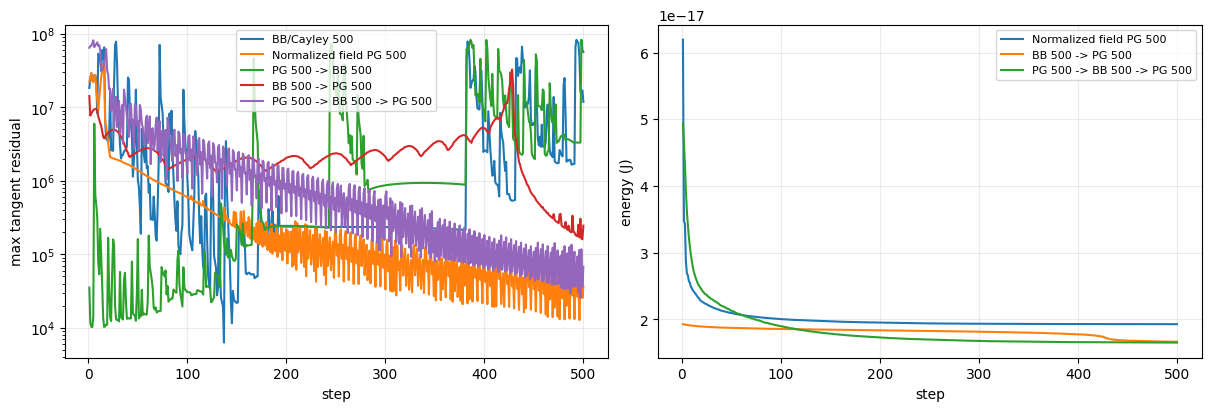

In [7]:
def plot_history(ax_residual, ax_energy, result):
    hist = result.get("history", {})
    if isinstance(hist, dict):
        if "max_g" in hist:
            steps = np.arange(1, len(hist["max_g"]) + 1)
            ax_residual.semilogy(steps, hist["max_g"], label=result["method"])
        return
    if not hist:
        return
    steps = [row["step"] for row in hist]
    ax_residual.semilogy(steps, [row["max_g"] for row in hist], label=result["method"])
    ax_energy.plot(steps, [row["energy_j"] for row in hist], label=result["method"])


fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for result in results:
    plot_history(axs[0], axs[1], result)
axs[0].set_xlabel("step")
axs[0].set_ylabel("max tangent residual")
axs[0].grid(True, alpha=0.25)
axs[0].legend(fontsize=8)
axs[1].set_xlabel("step")
axs[1].set_ylabel("energy (J)")
axs[1].grid(True, alpha=0.25)
axs[1].legend(fontsize=8)
plt.show()


## Save Results

In [8]:
output_dir = repo_root / "notebooks" / "MBIR" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"large_hybrid_relaxation_{run_mode}_{n}cells.npz"
best_by_residual = min(results, key=lambda row: row["max_g"])
best_by_energy = min(results, key=lambda row: row["energy_j"])
np.savez_compressed(
    output_path,
    run_mode=run_mode,
    shape_xyz=np.asarray(shape_xyz),
    method_names=np.asarray([row["method"] for row in results]),
    energy_j=np.asarray([row["energy_j"] for row in results], dtype=np.float64),
    max_g=np.asarray([row["max_g"] for row in results], dtype=np.float64),
    elapsed_s=np.asarray([row["elapsed_s"] for row in results], dtype=np.float64),
    best_residual_method=best_by_residual["method"],
    best_energy_method=best_by_energy["method"],
    best_residual_m_final=np.asarray(jax.device_get(best_by_residual["m_final"]), dtype=np.float32),
)
print(f"Saved summary and best-residual final state to {output_path}")


Saved summary and best-residual final state to /Users/landers/LiberTEM-holo/notebooks/MBIR/outputs/large_hybrid_relaxation_large_80cells.npz


## Interpretation

On the executed `80^3` large cube, the result is different from the small-cube smoke test in an important way: **normalized effective-field PG alone gives the best equilibrium residual**. BB/Cayley after PG is not a reliable final stage here; in this run it moves to a lower-quality residual state, and the direct `PG -> BB` sequence is actively bad.

Executed large-cube highlights:

- `BB/Cayley 500`: `max_g ~= 1.18e7`
- `Normalized field PG 500`: `max_g ~= 3.63e4`
- `BB 500 -> PG 500`: `max_g ~= 2.45e5`
- `PG 500 -> BB 500 -> PG 500`: `max_g ~= 6.76e4` and the lowest energy in this run

So for the large cube, the strongest residual result is **not** the original hybrid; it is normalized effective-field PG used as the primary relaxation/polishing method. The energy-best sequence is `PG -> BB -> PG`, but its residual is about `1.9x` worse than PG alone. For implicit differentiation readiness, the lower residual is probably the more important criterion.

Practical next step: factor `run_normalized_field_pg` into reusable solver code and test it inside the parameter-fit workflow as an optional forward relaxation mode. Keep BB/Cayley available as an energy-lowering stage, but do not assume it should be the final stage when the tangent equilibrium residual matters.
